In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
pandemic_graph=nx.read_graphml('pandemic_board_us.graphml')
ticket_graph=nx.read_graphml('ticket_to_ride_board_london.graphml')

### 1. How do you transform the graph of ”Ticket to ride” into a simple graph ? Apply this operation to transform it into a simple graph. From now on, we will refer to this transformed graph for the ”Ticket to ride” network.

In [3]:
ticket_graph.is_multigraph()

True

In [4]:
ticket_graph=nx.Graph(ticket_graph)

In [77]:
ticket_graph.is_multigraph()

False

### 2. Apply Depth First Search (DFS) graph traversal algorithm on the ”Ticket to ride” graph, starting from the ”British Museum” node. Do the same now starting from the ”Globe Theatre” node.

In [6]:
list(nx.dfs_edges(ticket_graph,'British Museum'))

[('British Museum', "Regent's Park"),
 ("Regent's Park", 'Baker Street'),
 ('Baker Street', 'Piccadilly Circus'),
 ('Piccadilly Circus', 'Hyde Park'),
 ('Hyde Park', 'Buckingham Palace'),
 ('Buckingham Palace', 'Trafalgar Square'),
 ('Trafalgar Square', 'Covent Garden'),
 ('Covent Garden', "St Paul's"),
 ("St Paul's", 'Globe Theatre'),
 ('Globe Theatre', 'Waterloo'),
 ('Waterloo', 'Big Ben'),
 ('Big Ben', 'Elephant & Castle'),
 ('Elephant & Castle', 'Tower of London'),
 ('Tower of London', 'Brick Lane'),
 ('Brick Lane', 'The Charterhouse'),
 ('The Charterhouse', "King's Cross")]

In [7]:
list(nx.dfs_edges(ticket_graph,'Globe Theatre'))

[('Globe Theatre', 'Waterloo'),
 ('Waterloo', 'Trafalgar Square'),
 ('Trafalgar Square', 'Piccadilly Circus'),
 ('Piccadilly Circus', 'Baker Street'),
 ('Baker Street', "Regent's Park"),
 ("Regent's Park", "King's Cross"),
 ("King's Cross", 'The Charterhouse'),
 ('The Charterhouse', 'British Museum'),
 ('British Museum', 'Covent Garden'),
 ('Covent Garden', "St Paul's"),
 ("St Paul's", 'Tower of London'),
 ('Tower of London', 'Brick Lane'),
 ('Tower of London', 'Elephant & Castle'),
 ('Elephant & Castle', 'Big Ben'),
 ('Big Ben', 'Buckingham Palace'),
 ('Buckingham Palace', 'Hyde Park')]

### 3. Determine the shortest path between the nodes ”Seattle” and ”Santo Domingo” in the ”Pandemic” graph. Check the result by applying Dijkstra’s algorithm by hand.

In [8]:
nx.shortest_path(pandemic_graph,'Seattle','Santo Domingo',method='dijkstra')

['Seattle',
 'San Francisco',
 'Los Angeles',
 'Guadalajara',
 'Ciudad de Mexico',
 'Havana',
 'Santo Domingo']

### 4. Apply the appropriate NetworkX function to determine the minimum-weight spanning tree of the two graphs. For each graph, is there a single minimum-weight spanning tree ? Check your results by applying Prim’s and Kruskal’s algorithms by hand.

In [9]:
pandi_krus=nx.minimum_spanning_tree(pandemic_graph,algorithm='kruskal')
pandi_prim=nx.minimum_spanning_tree(pandemic_graph,algorithm='prim')
ticket_krus=nx.minimum_spanning_tree(ticket_graph,algorithm='kruskal')
ticket_prim=nx.minimum_spanning_tree(ticket_graph,algorithm='prim')

In [19]:
def show(G,tilte):
    pos = nx.spring_layout(G, seed=42, k=0.6) 

    plt.figure(figsize=(10, 4))
    nx.draw_networkx_nodes(G, pos, node_size=1200, edgecolors="black", linewidths=1.5)
    nx.draw_networkx_labels(G, pos, font_size=9, font_weight="bold")
    nx.draw_networkx_edges(G, pos, width=2, alpha=0.4)
    plt.title(tilte, fontsize=14)
    plt.axis("off")
    plt.show()

In [30]:
pandi_krus.size("weight")

23.0

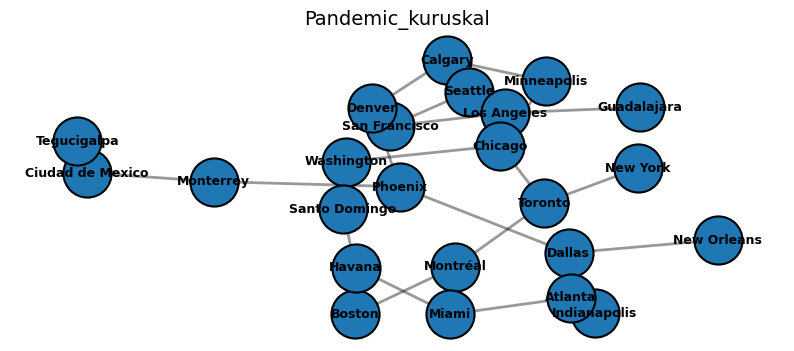

In [20]:
show(pandi_krus,"Pandemic_kuruskal")

In [31]:
pandi_prim.size("weight")

23.0

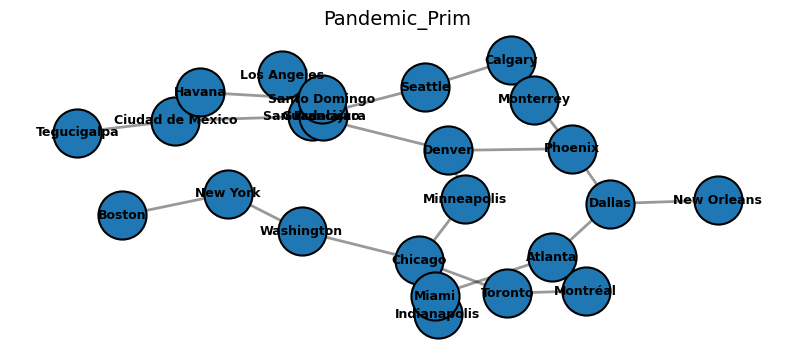

In [22]:
show(pandi_prim,"Pandemic_Prim")

In [32]:
ticket_krus.size("weight")

27.0

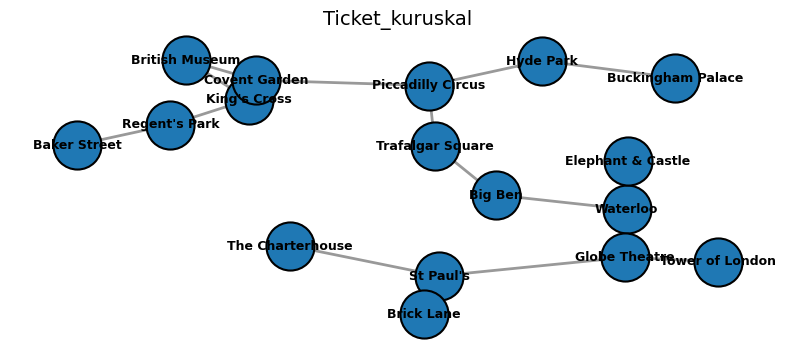

In [23]:
show(ticket_krus,"Ticket_kuruskal")

In [33]:
ticket_prim.size("weight")

27.0

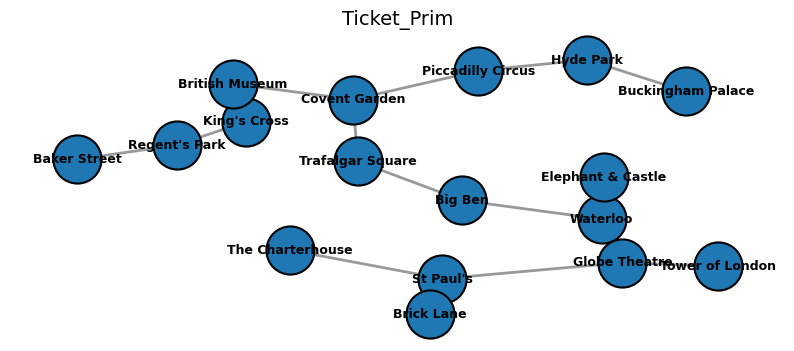

In [24]:
show(ticket_prim,"Ticket_Prim")

Text(0.5, 1.0, 'Prim in Ticket_London')

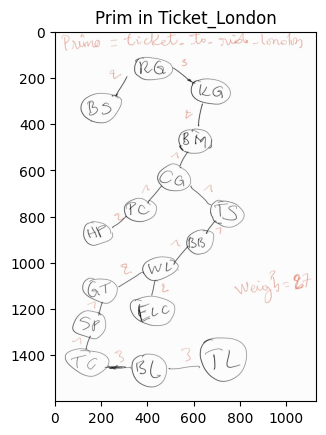

In [36]:
prim_hand=plt.imread('prim.jpeg')
plt.imshow(prim_hand)
plt.title('Prim in Ticket_London')

## We have the same resultat as 27

## 2 Second part (optional) : implementation of algorithms on graphs with Python

# <font color='red'> Depth First Search<font>

In [48]:
def my_deph_first(G,root,visited):
    if visited[root]:
        return
    print(root)
    visited[root]=True
    for v in G.neighbors(root):
        my_deph_first(G,v,visited)

In [ ]:
visited={i:False for i in pandemic_graph.nodes}
my_deph_first(pandemic_graph,'Calgary',visited)


Calgary
Seattle
San Francisco
Denver
Minneapolis
Chicago
Washington
New York
Toronto
Montréal
Boston
Atlanta
Dallas
Phoenix
Los Angeles
Guadalajara
Monterrey
New Orleans
Miami
Havana
Ciudad de Mexico
Tegucigalpa
Santo Domingo
Indianapolis


# <font color='red'> Dijkstra<font>

In [ ]:
def my_Dijkstr(G,source):
    dist={v:np.inf for v in G.nodes}
    previous={v:None for v in G.nodes}
    dist[source]=0
    copy_dist={}
    q=set([v for v in G.nodes])
    while len(q)!=0:
        copy_dist={i:val for i,val in dist.items() if i in q}
        u=min(copy_dist,key=copy_dist.get)
        q.remove(u)
        for v in G.neighbors(u):
            alt=dist[u]+G.get_edge_data(u, v)['weight']
            if alt<dist[v]:
                dist[v]=alt
                previous[v]=u
    return previous

In [93]:
my_Dijkstr(ticket_graph,'Globe Theatre')

({"Regent's Park": "King's Cross",
  "King's Cross": 'The Charterhouse',
  'Baker Street': 'British Museum',
  'British Museum': 'Covent Garden',
  'Piccadilly Circus': 'Covent Garden',
  'Hyde Park': 'Buckingham Palace',
  'Buckingham Palace': 'Big Ben',
  'Covent Garden': "St Paul's",
  'Trafalgar Square': 'Waterloo',
  'Big Ben': 'Waterloo',
  'Waterloo': 'Globe Theatre',
  'Globe Theatre': None,
  "St Paul's": 'Globe Theatre',
  'The Charterhouse': "St Paul's",
  'Brick Lane': "St Paul's",
  'Tower of London': 'Globe Theatre',
  'Elephant & Castle': 'Globe Theatre'},
 {"Regent's Park": 8,
  "King's Cross": 5,
  'Baker Street': 9,
  'British Museum': 5,
  'Piccadilly Circus': 5,
  'Hyde Park': 6,
  'Buckingham Palace': 5,
  'Covent Garden': 4,
  'Trafalgar Square': 4,
  'Big Ben': 3,
  'Waterloo': 2,
  'Globe Theatre': 0,
  "St Paul's": 1,
  'The Charterhouse': 2,
  'Brick Lane': 4,
  'Tower of London': 3,
  'Elephant & Castle': 2})

In [91]:
nx.shortest_path(ticket_graph,'Globe Theatre',"Regent's Park",method='dijkstra')

['Globe Theatre',
 "St Paul's",
 'Covent Garden',
 'British Museum',
 "Regent's Park"]